In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import glob
import h5py

import sys
sys.path.append('../../src')
from utils import smooth_curve
from Viz import show_images
from PlumeDataset import plume_dataset
from AutoAlign import align_plumes
from Velocity import VelocityCalculator
from PlumeMetrics import PlumeMetrics
from HorizontalLineProfileAnalyzer import HorizontalLineProfileAnalyzer

def analyze_function(P, V, plumes, threshold, index, viz_index, plume_name, 
                     align_parms={'align':False, 'coords':None, 'coords_standard':None}):
    # plumes = plumes[x_range[0]:x_range[1]]

    # align plumes
    if align_parms['align']:
        if align_parms['coords'] is None or align_parms['coords_standard'] is None:
            raise ValueError('Please provide the coordinates for alignment')
        else:
            plumes = align_plumes(plumes, align_parms['coords'], align_parms['coords_standard'])

    show_images(plumes[index][viz_index], img_per_row=16, img_height=1, title=plume_name)
    plt.show()

    areas, coords, labeled_images = P.calculate_area_for_plumes(plumes, threshold=threshold, return_format='dataframe')
    df_area = P.to_df(areas)

    print(plumes[index][viz_index].shape, areas[index][viz_index].shape, coords[index][viz_index].shape, labeled_images[index][viz_index].shape)
    P.viz_blob_plume(plumes[index][viz_index], areas[index][viz_index], coords[index][viz_index], labeled_images[index][viz_index], title=f'{plume_name}-Area')

    plume_positions, plume_distances, plume_velocities = V.calculate_distance_area_for_plumes(plumes)
    df_velocity = V.to_df(plume_positions, plume_distances, plume_velocities)
    print(plumes[index][viz_index].shape, plume_positions[index][viz_index].shape, plume_distances[index][viz_index].shape, plume_velocities[index][viz_index].shape)
    V.visualize_plume_positions(plumes[index][viz_index], plume_positions[index][viz_index], label_time=False, title=f'{plume_name}-plume position')

    df = pd.concat([df_velocity, df_area], axis=1)
    return df

# analysis frame parameters
start_position = (30, (51+208)//2) # start position of plume  (x, y)
position_range = (30, 376) # x position range
threshold = 20
time_interval = 500e-9  # 500ns

# visualize parameters
index = 3
# x_range = (8, 82) # x_range of frames to visualize
viz_index = list(np.arange(0, 32, 1))

P = PlumeMetrics(time_interval, threshold=threshold)
V = VelocityCalculator(time_interval, position_range, start_position, threshold=threshold)

#### experiment with line profile for better threshold value

['1-SrRuO3', '1-SrRuO3_Pre']


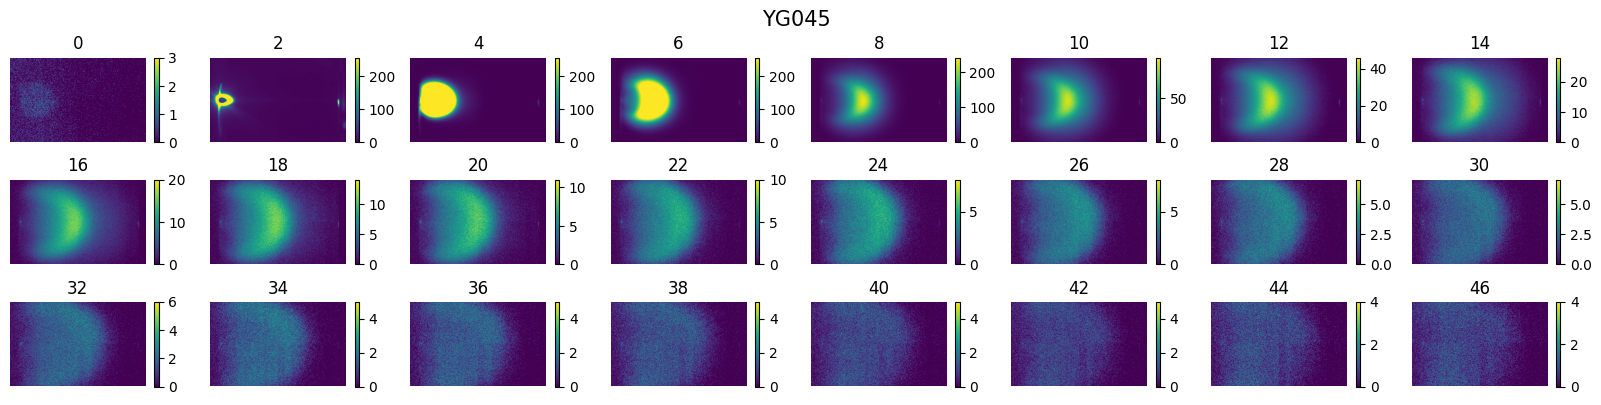

In [2]:
file = '../../datasets/YG045_YichenGuo_JulianGoddy_05092024.h5'

plume_ds = plume_dataset(file_path=file, group_name='PLD_Plumes')
keys = plume_ds.dataset_names()
print(keys)

labels = list(np.arange(0, 48, 2))
ds_name = file.split('/')[-1].split('_')[0]
plumes = plume_ds.load_plumes('1-SrRuO3')
show_images(plumes[5][labels], labels=labels, img_per_row=8, img_height=1, title=ds_name, show_colorbar=True)
plt.show()

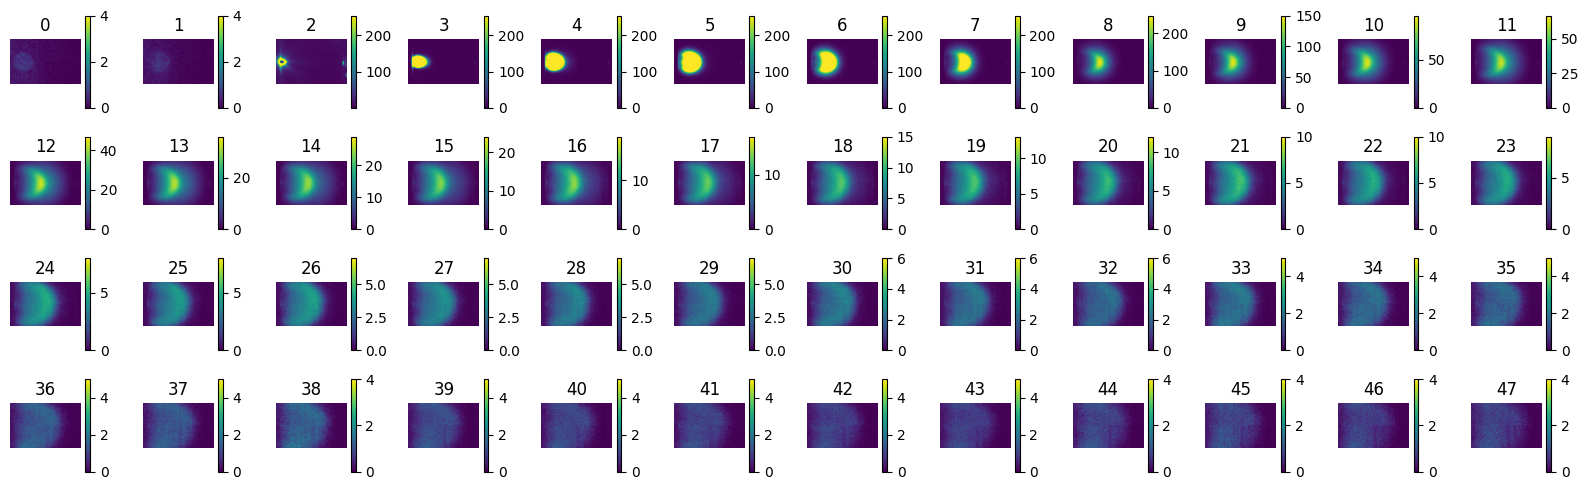

In [3]:
show_images(plumes[2][:48], img_per_row=12, img_height=1, show_colorbar=True)

In [4]:
sample_imgs = plumes[2][[1,3,5,7,10,15,22,30,40]]

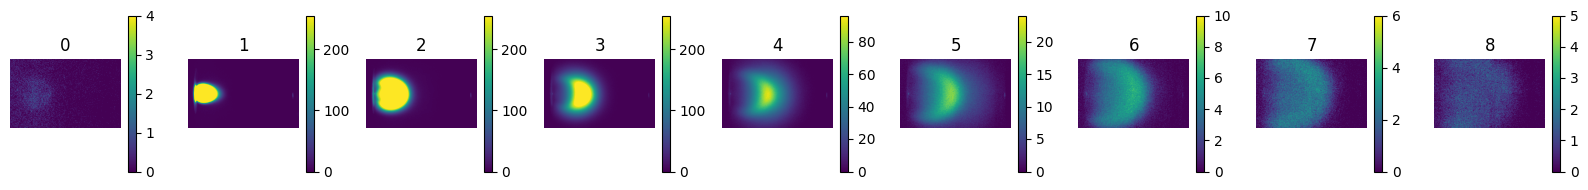

In [5]:
show_images(sample_imgs, img_per_row=9, img_height=1, show_colorbar=True)

No decreases found in the profile.


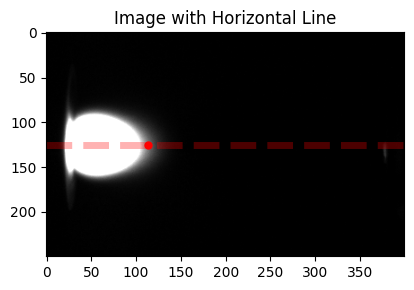

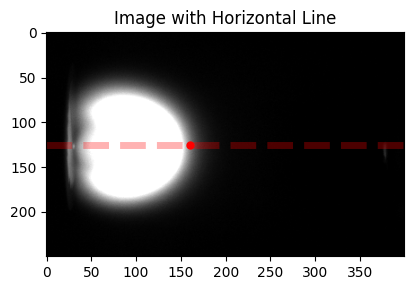

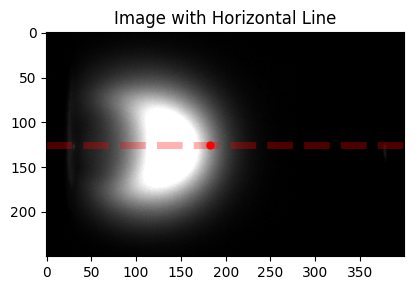

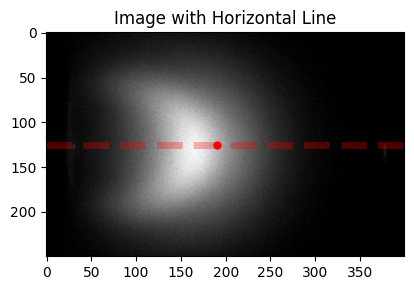

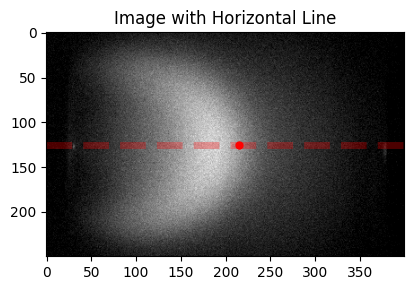

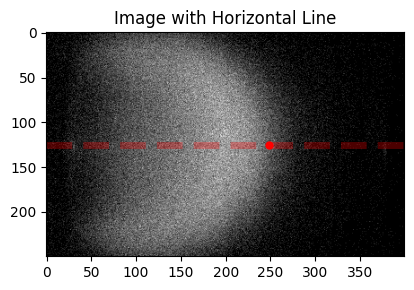

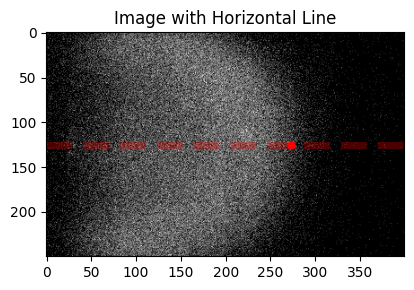

No decreases found in the profile.


In [31]:
for i, image in enumerate(sample_imgs):
    # plt.imshow(image)
    # plt.title(f'Image {i}')
    # plt.colorbar()
    # plt.show()
    analyzer = HorizontalLineProfileAnalyzer(image)
    profile = analyzer.extract_profile(row=125, line_width=5)
    position, magnitude = analyzer.detect(target_x=30, show_image=True, show_profile=False, show_difference=False)

Largest decrease found at row: 106


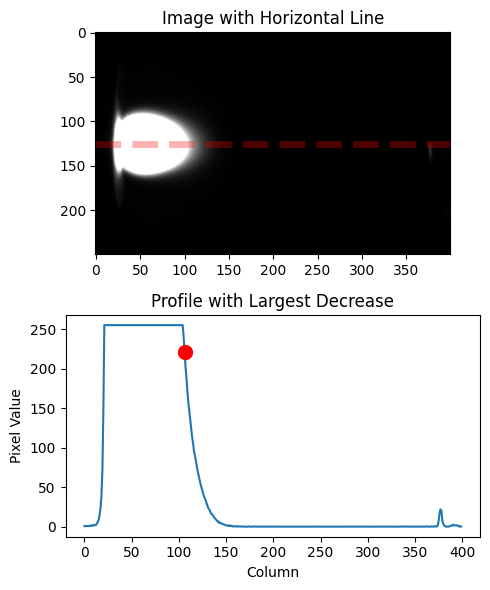

In [7]:
# Example usage:
analyzer = HorizontalLineProfileAnalyzer(image)
profile = analyzer.extract_profile(row=125, line_width=5)
position, magnitude = analyzer.visualize(show_image=True, show_profile=True, show_difference=False)